In [ ]:
import matplotlib.pyplot as plt
import tensorflow as tf
import kagglehub
import os
import shutil
import tarfile
from tensorflow.keras.models import Model, load_model
from tensorflow.keras.layers import Input, Flatten
from tensorflow.keras.layers import Dropout, Lambda
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.callbacks import ReduceLROnPlateau, CSVLogger
from tensorflow.keras import backend as K
import numpy as np
import tensorflow as tf
import pandas as pd
from tensorflow.keras.models import load_model
from tensorflow.keras.metrics import Precision, Recall, MeanIoU

%matplotlib inline
%load_ext tensorboard

from tensorflow.keras.layers import (
    Input,
    Conv2D,
    Conv2DTranspose,
    MaxPooling2D,
    BatchNormalization,
    Activation,
    concatenate,
    add,
    multiply
)

from sklearn.datasets import *

## Mount Google Drive to access preprocessed datasets

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Check if a GPU is available for TensorFlow training

In [ ]:
gpus = tf.config.list_physical_devices('GPU')

if gpus:
    print(f"SUCCESS: {len(gpus)} GPU(s) detected!")
    print(f"Device Name: {gpus[0].name}")
else:
    print(" ERROR: No GPU detected. You are running on CPU.")

SUCCESS: 1 GPU(s) detected!
Device Name: /physical_device:GPU:0


## Extract the preprocessed dataset from the ZIP file into the working directory

In [ ]:
import zipfile
import os

# Path to the ZIP file containing the preprocessed dataset
zip_path = "/content/drive/MyDrive/segmentatioImage/processed_unet.zip"

# Directory where the dataset will be extracted
base_path = "/content/processed_unet"

# Create the destination folder if it does not exist
os.makedirs(base_path, exist_ok=True)

# Extract the ZIP file
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(base_path)

print("Dataset extracted successfully")

Dataset extracted successfully


## Display the files and folders extracted in the dataset directory

In [ ]:
print(os.listdir(base_path))

['images', 'masks']


In [ ]:
IMAGES_DIR = os.path.join("/content/processed_unet/images")
MASKS_DIR = os.path.join("/content/processed_unet/masks")


## Prepare and split the dataset into training, validation, and test sets based on patient IDs

In [ ]:
# Split the dataset into training, validation, and test sets based on patient IDs
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import Sequence
import os
import numpy as np

# =========================
# 1. List image and mask files
# =========================

images_list = sorted(os.listdir(IMAGES_DIR))
masks_list = sorted(os.listdir(MASKS_DIR))

# Extract unique patient IDs
patient_ids = sorted(list(set([
    "_".join(img.split("_")[:2])
    for img in images_list
])))

print("Total patients:", len(patient_ids))


# =========================
# 2. Split patients into train, validation, and test sets
# =========================

train_patients, temp_patients = train_test_split(
    patient_ids,
    test_size=0.2,
    random_state=42
)

val_patients, test_patients = train_test_split(
    temp_patients,
    test_size=0.5,
    random_state=42
)

print("Train patients:", len(train_patients))
print("Validation patients:", len(val_patients))
print("Test patients:", len(test_patients))


# =========================
# 3. Create image and mask lists for each split
# =========================

train_images, train_masks = [], []
val_images, val_masks = [], []
test_images, test_masks = [], []

for img_name, mask_name in zip(images_list, masks_list):

    patient_id = "_".join(img_name.split("_")[:2])

    if patient_id in train_patients:
        train_images.append(img_name)
        train_masks.append(mask_name)

    elif patient_id in val_patients:
        val_images.append(img_name)
        val_masks.append(mask_name)

    elif patient_id in test_patients:
        test_images.append(img_name)
        test_masks.append(mask_name)

print("Train images:", len(train_images))
print("Validation images:", len(val_images))
print("Test images:", len(test_images))

Total patients: 800
Train patients: 640
Validation patients: 80
Test patients: 80
Train images: 37553
Validation images: 4799
Test images: 4715


## Count the total number of images and segmentation masks in the dataset

In [ ]:
num_images = len(os.listdir(IMAGES_DIR))
num_masks = len(os.listdir(MASKS_DIR))

print(f"Cantidad de imágenes: {num_images}")
print(f"Cantidad de máscaras: {num_masks}")

Cantidad de imágenes: 47067
Cantidad de máscaras: 47067


## Custom data generator for loading and preprocessing brain tumor MRI images and segmentation masks in batches

In [ ]:
class BrainTumorGenerator(Sequence):

    def __init__(
        self,
        image_files,
        mask_files,
        images_dir,
        masks_dir,
        batch_size=16,
        shuffle=True
    ):
        self.image_files = image_files
        self.mask_files = mask_files
        self.images_dir = images_dir
        self.masks_dir = masks_dir
        self.batch_size = batch_size
        self.shuffle = shuffle

        self.indexes = np.arange(len(self.image_files))
        self.on_epoch_end()

    def __len__(self):
        return int(np.ceil(len(self.image_files) / self.batch_size))

    def __getitem__(self, index):

        batch_indexes = self.indexes[
            index * self.batch_size:(index + 1) * self.batch_size
        ]

        batch_images = []
        batch_masks = []

        for i in batch_indexes:

            img = np.load(
                os.path.join(self.images_dir, self.image_files[i])
            )

            mask = np.load(
                os.path.join(self.masks_dir, self.mask_files[i])
            )

            # images
            img = img.astype(np.float32) / 255.0

            # multiclass mask
            mask = mask.astype(np.uint8)
            mask[mask == 4] = 3

            # add chanel to the mask
            mask = np.expand_dims(mask, axis=-1)

            batch_images.append(img)
            batch_masks.append(mask)

        X = np.array(batch_images, dtype=np.float32)
        y = np.array(batch_masks, dtype=np.uint8)

        return X, y

    def on_epoch_end(self):
        if self.shuffle:
            np.random.shuffle(self.indexes)

# Create data generators for training, validation, and testing datasets

In [ ]:
final_train_generator = BrainTumorGenerator(
    train_images,
    train_masks,
    IMAGES_DIR,
    MASKS_DIR,
    batch_size=16,
    shuffle=True
)

final_val_generator = BrainTumorGenerator(
    val_images,
    val_masks,
    IMAGES_DIR,
    MASKS_DIR,
    batch_size=16,
    shuffle=False
)

test_generator = BrainTumorGenerator(
    test_images,
    test_masks,
    IMAGES_DIR,
    MASKS_DIR,
    batch_size=16,
    shuffle=False
)

# Define Dice coefficient metric and Dice loss function for multi-class image segmentation

In [ ]:
@tf.keras.utils.register_keras_serializable()
def dice_coef(y_true, y_pred, smooth=1e-7):
    '''
    Dice coefficient for 10 categories. Ignores background pixel label 0
    Pass to model as metric during compile statement
    '''
    y_true_f = K.flatten(K.one_hot(K.cast(y_true, 'int32'), num_classes=4)[...,1:])
    y_pred_f = K.flatten(y_pred[...,1:])
    intersect = K.sum(y_true_f * y_pred_f, axis=-1)
    denom = K.sum(y_true_f + y_pred_f, axis=-1)
    return K.mean((2. * intersect / (denom + smooth)))

@tf.keras.utils.register_keras_serializable()
def dice_coef_loss(y_true, y_pred):
    '''
    Dice loss to minimize. Pass to model as loss during compile statement
    '''
    return 1 - dice_coef(y_true, y_pred)

In [ ]:
@tf.keras.utils.register_keras_serializable()
def mean_iou(y_true, y_pred, smooth=1e-7):

    # Convert predictions from probabilities to labels
    y_pred = tf.argmax(y_pred, axis=-1)

    # Remove last dimension from ground truth
    y_true = tf.squeeze(y_true, axis=-1)

    # Convert to int32
    y_true = tf.cast(y_true, tf.int32)
    y_pred = tf.cast(y_pred, tf.int32)

    iou_scores = []

    # Ignore background class (0)
    for class_id in range(1, 4):

        true_class = tf.equal(y_true, class_id)
        pred_class = tf.equal(y_pred, class_id)

        intersection = tf.reduce_sum(
            tf.cast(true_class & pred_class, tf.float32)
        )

        union = tf.reduce_sum(
            tf.cast(true_class | pred_class, tf.float32)
        )

        iou = (intersection + smooth) / (union + smooth)

        iou_scores.append(iou)

    return tf.reduce_mean(iou_scores)

In [ ]:
@tf.keras.utils.register_keras_serializable()
def dice_crossentropy(y_true, y_pred):

    dice = dice_coef_loss(y_true, y_pred)

    ce = tf.keras.losses.sparse_categorical_crossentropy(
        y_true,
        y_pred
    )

    return dice + ce

In [ ]:
import time
from tensorflow.keras.callbacks import Callback

class TrainingTimer(Callback):

    def on_train_begin(self, logs=None):
        self.train_start = time.time()

    def on_train_end(self, logs=None):
        total_time = time.time() - self.train_start

        hours = int(total_time // 3600)
        minutes = int((total_time % 3600) // 60)
        seconds = int(total_time % 60)

        print("\n===== TRAINING TIME =====")
        print(f"Total training time: {hours}h {minutes}m {seconds}s")

timer_callback = TrainingTimer()

# Define the  attention U-Net model architecture

In [ ]:
def conv_block(input_tensor, num_filters):

    x = Conv2D(num_filters, (3, 3), padding='same')(input_tensor)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)

    x = Conv2D(num_filters, (3, 3), padding='same')(x)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)

    return x

def encoder_block(x, num_filters):
    x = conv_block(x, num_filters)
    p = MaxPooling2D((2, 2),strides=(2,2))(x)
    return x, p



def attention_gate(gating_signal, skip_connection, filters):

    theta_x = Conv2D(filters, (1,1), padding='same')(skip_connection)
    phi_g = Conv2D(filters, (1,1), padding='same')(gating_signal)
    add_xg = add([theta_x, phi_g])
    add_xg = Activation('relu')(add_xg)
    psi = Conv2D(1, (1,1), padding='same')(add_xg)
    psi = Activation('sigmoid')(psi)
    attention = multiply([skip_connection, psi])

    return attention


def decoder_block(input_tensor, skip_tensor, num_filters):

    decoder = Conv2DTranspose( num_filters,(2,2),strides=(2,2),padding='same')(input_tensor)
    skip_tensor = attention_gate(decoder,skip_tensor,num_filters )
    decoder = concatenate([decoder, skip_tensor])
    decoder = conv_block(decoder, num_filters)

    return decoder


def get_attention_unet(Kernels,IMG_HEIGHT=128, IMG_WIDTH=128, IMG_CHANNELS=4,N_CLASSES=4):

    inputs = Input((IMG_HEIGHT, IMG_WIDTH, IMG_CHANNELS))


    encoder1, encoder_pool1 = encoder_block(inputs, Kernels)
    encoder2, encoder_pool2 = encoder_block(encoder_pool1, Kernels*2)
    encoder3, encoder_pool3 = encoder_block(encoder_pool2, Kernels*4)
    encoder4, encoder_pool4 = encoder_block(encoder_pool3, Kernels*8)


    center = conv_block(encoder_pool4,Kernels*16)


    decoder3 = decoder_block(center, encoder4, Kernels * 8)
    decoder2 = decoder_block(decoder3, encoder3, Kernels * 4)
    decoder1 = decoder_block(decoder2, encoder2, Kernels * 2)
    decoder0 = decoder_block(decoder1, encoder1, Kernels)


    outputs = Conv2D(N_CLASSES,(1, 1),activation='softmax')(decoder0)


    model = Model(inputs=[inputs],outputs=[outputs])

    model.compile(
        optimizer='adam',
        loss= dice_crossentropy,
        metrics=[dice_coef,mean_iou]

    )

    return model

In [ ]:
model = get_attention_unet(16)
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 4)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 128, 128,  │        592 │ input_layer[0][0] │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 128, 128,  │         64 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 128, 128,  │          0 │ batch_normalizat… │
│ (Activation)        │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 128, 128,  │      2,320 │ activation[0][0]  │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 128,  │         64 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 128, 128,  │          0 │ batch_normalizat… │
│ (Activation)        │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 64, 64,    │          0 │ activation_1[0][… │
│ (MaxPooling2D)      │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 64, 64,    │      4,640 │ max_pooling2d[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 64,    │        128 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 64, 64,    │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 64, 64,    │      9,248 │ activation_2[0][… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 64,    │        128 │ conv2d_3[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_3        │ (None, 64, 64,    │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 32, 32,    │          0 │ activation_3[0][… │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 32, 32,    │     18,496 │ max_pooling2d_1[… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 32,    │        256 │ conv2d_4[0][0]  

 Total params: 1,991,432 (7.60 MB)

 Trainable params: 1,988,488 (7.59 MB)

 Non-trainable params: 2,944 (11.50 KB)

## Cross Valitation

In [ ]:
from sklearn.model_selection import KFold
kf = KFold(n_splits=2,shuffle=True,random_state=42)

filter_options = [16,32]


best_mean_dice = -1

best_filters = None

for filters in filter_options:

    fold_no = 1

    train_dice_scores,train_Iou_scores,val_dice_scores = [],[],[]
    val_Iou_scores,train_loss,val_loss = [],[],[]


    for train_idx, val_idx in kf.split(train_patients):

        print(f"\n========== FOLD {fold_no} ==========")

        # ======================================
        # PATIENT SPLIT
        # ======================================

        fold_train_patients = [train_patients[i] for i in train_idx]

        fold_val_patients = [train_patients[i] for i in val_idx]

        # ======================================
        # IMAGE/MASK LISTS
        # ======================================

        fold_train_images = []
        fold_train_masks = []

        fold_val_images = []
        fold_val_masks = []

        for img_name, mask_name in zip(images_list,masks_list):

            patient_id = "_".join(img_name.split("_")[:2])

            if patient_id in fold_train_patients:

                fold_train_images.append(img_name)
                fold_train_masks.append(mask_name)

            elif patient_id in fold_val_patients:

                fold_val_images.append(img_name)
                fold_val_masks.append(mask_name)


        fold_train_generator = BrainTumorGenerator(
            fold_train_images,
            fold_train_masks,
            IMAGES_DIR,
            MASKS_DIR,
            batch_size=16,
            shuffle=True
        )

        fold_val_generator = BrainTumorGenerator(
            fold_val_images,
            fold_val_masks,
            IMAGES_DIR,
            MASKS_DIR,
            batch_size=16,
            shuffle=False
        )

        # ======================================
        # MODEL
        # ======================================

        model = get_attention_unet(filters)


        # ======================================
        # CALLBACKS
        # ======================================

        earlystopper = EarlyStopping(
            monitor='val_dice_coef',
            mode='max',
            patience=5,
            verbose=1,
            restore_best_weights=True)


        reduce_lr = ReduceLROnPlateau(
            monitor='val_loss',
            factor=0.5,
            patience=3,
            min_lr=1e-7,
            verbose=1)

        # ======================================
        # TRAIN
        # ======================================

        history = model.fit(
            fold_train_generator,
            validation_data=fold_val_generator,
            epochs=4,
            callbacks=[
                earlystopper,
                reduce_lr
            ]
        )

        # ======================================
        # EVALUATE
        # ======================================

        scores_train = model.evaluate(fold_train_generator )
        scores_val = model.evaluate(fold_val_generator)

        train_loss.append(scores_train[0])
        train_dice_scores.append(scores_train[1])
        current_dice = scores_val[1]
        train_Iou_scores.append(scores_train[2])

        val_loss.append(scores_val[0])
        val_dice_scores.append(scores_val[1])
        val_Iou_scores.append(scores_val[2])


        fold_no += 1

    mean_dice = np.mean(val_dice_scores)

    if mean_dice > best_mean_dice:
      best_mean_dice = mean_dice
      best_filters = filters



========== FOLD 1 ==========


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/4
1186/1186 ━━━━━━━━━━━━━━━━━━━━ 149s 91ms/step - dice_coef: 0.5282 - loss: 0.6512 - mean_iou: 0.4770 - val_dice_coef: 0.6512 - val_loss: 0.4064 - val_mean_iou: 0.5032 - learning_rate: 0.0010
Epoch 2/4
1186/1186 ━━━━━━━━━━━━━━━━━━━━ 80s 67ms/step - dice_coef: 0.7962 - loss: 0.2374 - mean_iou: 0.6697 - val_dice_coef: 0.7461 - val_loss: 0.2940 - val_mean_iou: 0.5801 - learning_rate: 0.0010
Epoch 3/4
1186/1186 ━━━━━━━━━━━━━━━━━━━━ 79s 67ms/step - dice_coef: 0.8248 - loss: 0.2042 - mean_iou: 0.7081 - val_dice_coef: 0.7623 - val_loss: 0.2787 - val_mean_iou: 0.6090 - learning_rate: 0.0010
Epoch 4/4
1186/1186 ━━━━━━━━━━━━━━━━━━━━ 82s 69ms/step - dice_coef: 0.8389 - loss: 0.1878 - mean_iou: 0.7281 - val_dice_coef: 0.7786 - val_loss: 0.2572 - val_mean_iou: 0.6047 - learning_rate: 0.0010
Restoring model weights from the end of the best epoch: 4.
1186/1186 ━━━━━━━━━━━━━━━━━━━━ 21s 17ms/step - dice_coef: 0.8442 - loss: 0.1818 - mean_iou: 0.7228
1162/1162 ━━━━━━━━━━━━━━━━━━━━ 19s 17ms/step 

In [ ]:
print("Best Mean Dice Score:", best_mean_dice)
print("Best Number of Filters:", best_filters)

Best Mean Dice Score: 0.7765162587165833
Best Number of Filters: 32


# Define training callbacks for early stopping, model checkpointing, learning rate reduction, and training logging

In [ ]:
earlystopper = EarlyStopping(
    monitor='val_dice_coef',
    mode='max',
    patience=5,
    verbose=1,
    restore_best_weights=True
)

checkpointer = ModelCheckpoint(
    'model-best.keras',
    verbose=1,
    save_best_only=True,
    monitor='val_dice_coef',
    mode='max'
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    min_lr=1e-7,
    verbose=1
)

csv_logger = CSVLogger('training_log.csv')

# Train the U-Net model using the training and validation generators

In [ ]:
model=get_attention_unet(best_filters)

modeltrain = model.fit(
    final_train_generator,
    validation_data=final_val_generator,
    epochs=30,
    callbacks=[
        earlystopper,
        checkpointer,
        reduce_lr,
        timer_callback
    ]
)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/30
2347/2348 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - dice_coef: 0.5136 - loss: 0.6237 - mean_iou: 0.4212
Epoch 1: val_dice_coef improved from None to 0.77606, saving model to model-best.keras

Epoch 1: finished saving model to model-best.keras
2348/2348 ━━━━━━━━━━━━━━━━━━━━ 172s 58ms/step - dice_coef: 0.6853 - loss: 0.3757 - mean_iou: 0.5576 - val_dice_coef: 0.7761 - val_loss: 0.2583 - val_mean_iou: 0.6273 - learning_rate: 0.0010
Epoch 2/30
2348/2348 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - dice_coef: 0.8135 - loss: 0.2174 - mean_iou: 0.6881
Epoch 2: val_dice_coef improved from 0.77606 to 0.77617, saving model to model-best.keras

Epoch 2: finished saving model to model-best.keras
2348/2348 ━━━━━━━━━━━━━━━━━━━━ 121s 51ms/step - dice_coef: 0.8206 - loss: 0.2092 - mean_iou: 0.6983 - val_dice_coef: 0.7762 - val_loss: 0.2560 - val_mean_iou: 0.6477 - learning_rate: 0.0010
Epoch 3/30
2347/2348 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - dice_coef: 0.8407 - loss: 0.1859 - mean_iou: 0.7257
Epoch 3: val

# Evaluate the trained model on the test dataset and display performance metrics

In [ ]:
best_epoch = np.argmax(modeltrain.history['val_dice_coef'])

print(f"Best Epoch: {best_epoch + 1}")

print("\n===== LOSS =====")
print(f"Train Loss: {modeltrain.history['loss'][best_epoch]:.4f}")
print(f"Validation Loss: {modeltrain.history['val_loss'][best_epoch]:.4f}")

print("\n===== DICE =====")
print(f"Train Dice: {modeltrain.history['dice_coef'][best_epoch]:.4f}")
print(f"Validation Dice: {modeltrain.history['val_dice_coef'][best_epoch]:.4f}")

print("\n===== IoU =====")
print(f"Train IoU: {modeltrain.history['mean_iou'][best_epoch]:.4f}")
print(f"Validation IoU: {modeltrain.history['val_mean_iou'][best_epoch]:.4f}")

Best Epoch: 14

===== LOSS =====
Train Loss: 0.1002
Validation Loss: 0.1978

===== DICE =====
Train Dice: 0.9139
Validation Dice: 0.8337

===== IoU =====
Train IoU: 0.8411
Validation IoU: 0.6904


# Load the best saved model and evaluate its performance on the test dataset


In [ ]:
best_model = load_model(
    'model-best.keras',
    custom_objects={
        'dice_coef': dice_coef
    }
)

In [ ]:
resultstest = best_model.evaluate(test_generator)

for name, value in zip(best_model.metrics_names, resultstest ):
    print(f"{name}: {value:.4f}")

295/295 ━━━━━━━━━━━━━━━━━━━━ 5s 18ms/step - dice_coef: 0.8225 - loss: 0.2102 - mean_iou: 0.6839
loss: 0.2102
compile_metrics: 0.8225


# Compute multi-class Dice scores and visualize MRI slices with ground truth and predicted tumor segmentations

In [ ]:
def multiclass_dice_score(y_true, y_pred, num_classes=4, smooth=1e-6, include_background=True):
    dice_scores = []

    start_class = 0 if include_background else 1

    for class_id in range(start_class, num_classes):
        y_true_class = (y_true == class_id).astype(np.uint8)
        y_pred_class = (y_pred == class_id).astype(np.uint8)

        intersection = np.sum(y_true_class * y_pred_class)

        dice = (2.0 * intersection + smooth) / (
            np.sum(y_true_class) + np.sum(y_pred_class) + smooth
        )

        dice_scores.append(dice)

    return np.mean(dice_scores), dice_scores


def visualize_slice_80(model, patient_id, slice_num):
    image_name = f"{patient_id}_slice_{slice_num}.npy"

    img = np.load(os.path.join(IMAGES_DIR, image_name))
    img_input = img.astype(np.float32) / 255.0

    true_mask = np.load(os.path.join(MASKS_DIR, image_name)).astype(np.uint8)
    true_mask[true_mask == 4] = 3

    pred_mask = model.predict(
        np.expand_dims(img_input, axis=0),
        verbose=0
    )[0]

    pred_classes = np.argmax(pred_mask, axis=-1).astype(np.uint8)

    dice_mean, dice_per_class = multiclass_dice_score(
        true_mask,
        pred_classes,
        num_classes=4,
        include_background=False
    )

    print("True mask classes:", np.unique(true_mask))
    print("Predicted classes:", np.unique(pred_classes))

    print("Pixels clase 3 reales:",
          np.sum(true_mask == 3))

    print("Pixels clase 3 predichos:",
      np.sum(pred_classes == 3))

    fig, axes = plt.subplots(1, 4, figsize=(20, 5))

    axes[0].imshow(img[:, :, 0], cmap="gray")
    axes[0].imshow(true_mask, cmap="jet", alpha=0.5, vmin=0, vmax=4)
    axes[0].set_title("Overlay Original")
    axes[0].axis("off")

    axes[1].imshow(true_mask, cmap="jet", vmin=0, vmax=4)
    axes[1].set_title("Original Segmentation")
    axes[1].axis("off")

    axes[2].imshow(pred_classes, cmap="jet", vmin=0, vmax=4)
    axes[2].set_title("Predicted Segmentation")
    axes[2].axis("off")

    axes[3].imshow(img[:, :, 0], cmap="gray")
    axes[3].imshow(pred_classes, cmap="jet", alpha=0.5, vmin=0, vmax=4)
    axes[3].set_title(f"Overlay Prediction\nMean Dice: {dice_mean:.4f}")
    axes[3].axis("off")

    plt.tight_layout()
    plt.show()

    print(f"Mean Multiclass Dice: {dice_mean:.4f}")
    print(f"Dice clase 0: {dice_per_class[0]:.4f}")
    print(f"Dice clase 1: {dice_per_class[1]:.4f}")
    print(f"Dice clase 2: {dice_per_class[2]:.4f}")
    #print(f"Dice clase 3: {dice_per_class[3]:.4f}")



True mask classes: [0 1 2 3]
Predicted classes: [0 1 2 3]
Pixels clase 3 reales: 140
Pixels clase 3 predichos: 157


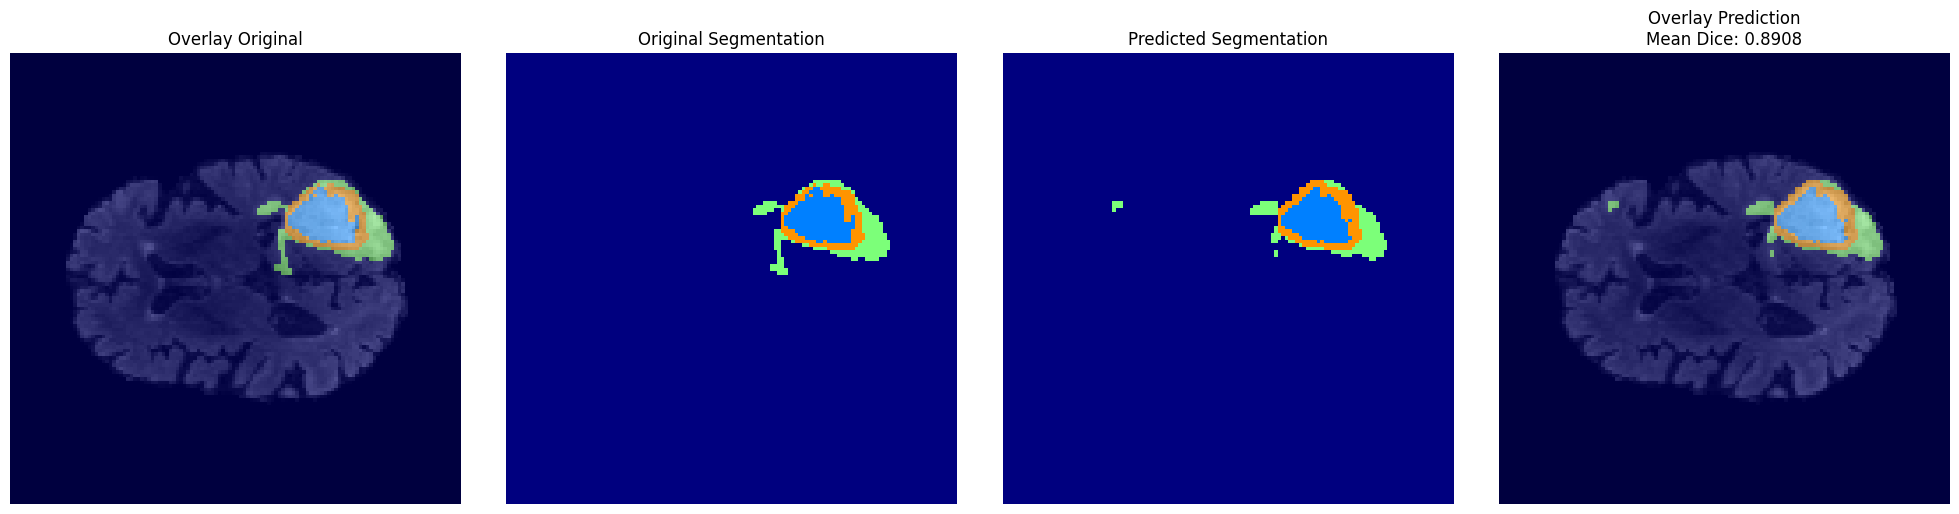

Mean Multiclass Dice: 0.8908
Dice clase 0: 0.9655
Dice clase 1: 0.8044
Dice clase 2: 0.9024


In [ ]:
visualize_slice_80(model, "BraTS2021_00020",70)